In [1]:
import os, glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nugraph as ng

torch.set_float32_matmul_precision("medium")

DATA_PATH = "/home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly"
RUN_NAME = "merged1_Aug20_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep45_bs32_in8_sp5"

ckpts = glob.glob(f"/home/apaudel/NuGraph/logs/{RUN_NAME}/**/*.ckpt", recursive=True)
assert ckpts, f"No checkpoint found for {RUN_NAME}"
CKPT = max(ckpts, key=os.path.getmtime)

print("DATA_PATH =", DATA_PATH)
print("RUN_NAME  =", RUN_NAME)
print("CKPT      =", CKPT)

Data = ng.data.H5DataModule
Model = ng.models.NuGraph3

nudata = Data(
    DATA_PATH,
    batch_size=32,
    num_workers=0,
    model=Model,
    shuffle="random",
    featext3d=True,
)

model = Model.load_from_checkpoint(CKPT)
model.eval()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("\nDataset lengths:")
print("train =", len(nudata.train_dataset))
print("val   =", len(nudata.val_dataset))
print("test  =", len(nudata.test_dataset))

print("\nModel sanity:")
print("use_optical =", model.use_optical)
print("PMT-PMT active =", model.optical_net.use_pmt_pmt)
print("sp_net active =", model.encoder.sp_net is not None)

DATA_PATH = /home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly
RUN_NAME  = merged1_Aug20_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep45_bs32_in8_sp5
CKPT      = /home/apaudel/NuGraph/logs/merged1_Aug20_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep45_bs32_in8_sp5/version_0/checkpoints/epoch=44-step=42300.ckpt

Dataset lengths:
train = 30080
val   = 1672
test  = 1672

Model sanity:
use_optical = True
PMT-PMT active = True
sp_net active = True


,N test,axis cos mean,axis cos median,axis angle mean deg,axis angle median deg,axis angle p68 deg,axis angle p90 deg,frac axis angle < 10 deg,frac axis angle < 20 deg,frac axis angle < 30 deg,axis ux abs mean,axis uy abs mean,axis uz abs mean,pred vertex mean err cm,pred vertex median err cm,pred vertex p68 err cm,pred vertex p90 err cm,fixed v_pred median err cm
0,1672,0.6624,0.75,43.670502,41.4109,56.299301,79.231903,0.0682,0.1998,0.3541,0.3611,0.3603,0.369,186.072998,185.149002,249.930298,329.724792,5.4797


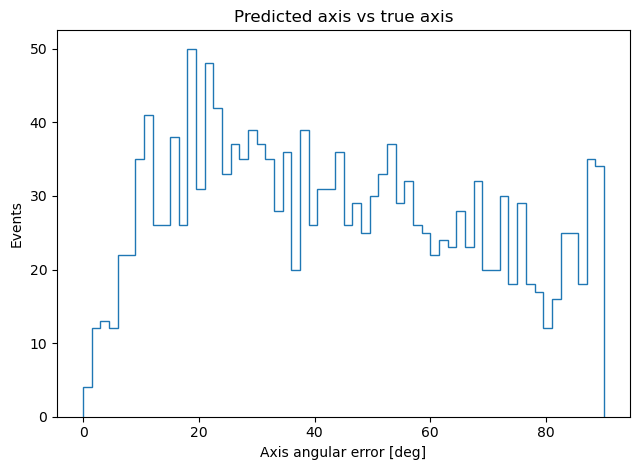

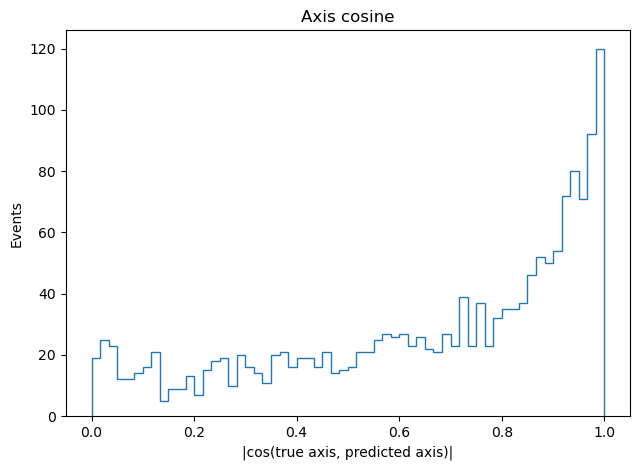

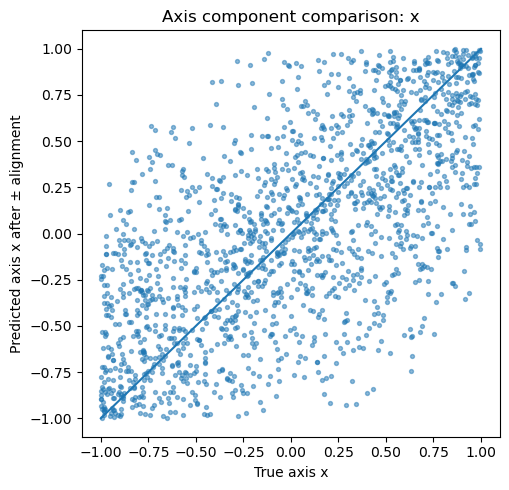

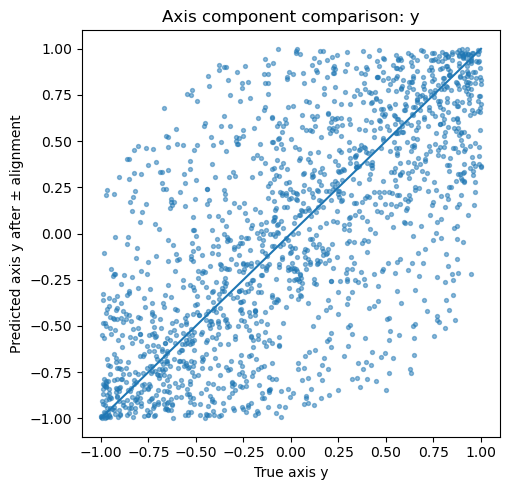

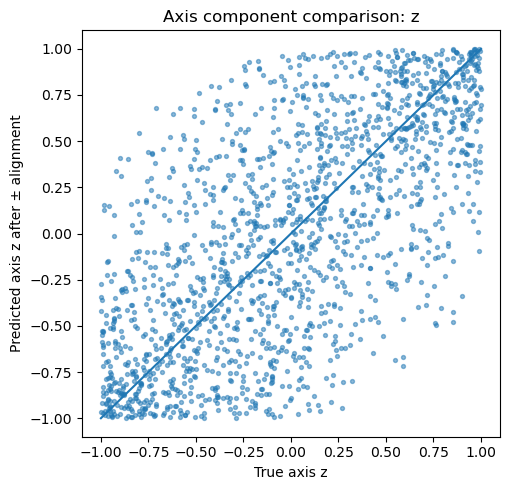

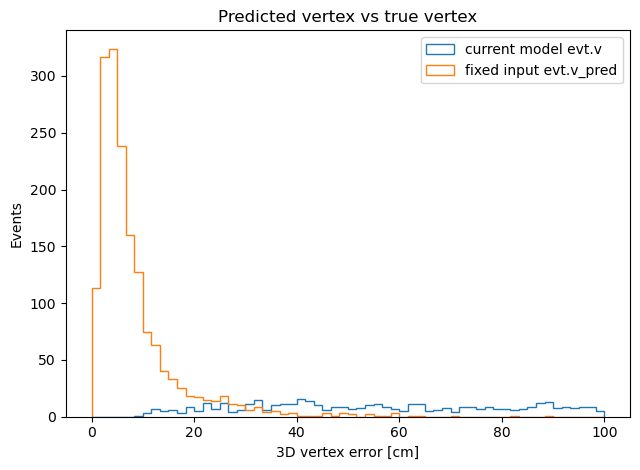

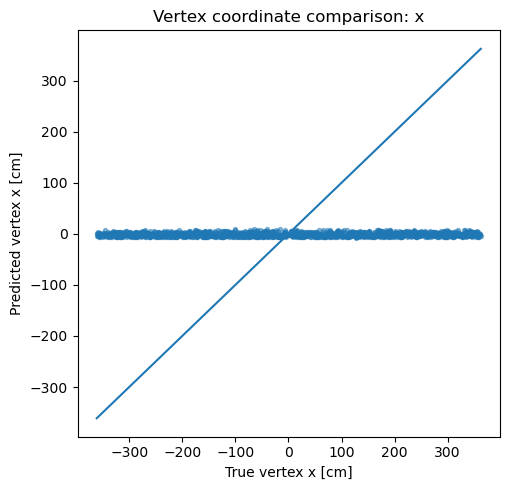

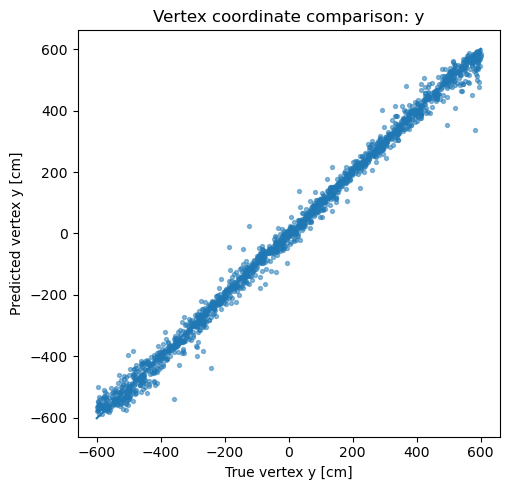

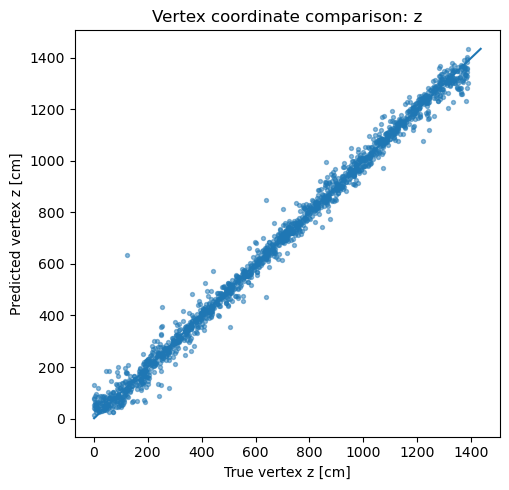

In [2]:
rows = []

with torch.no_grad():
    for batch in nudata.test_dataloader():
        batch = batch.to(device)
        model(batch, "test")

        evt = batch["evt"]

        rows.append({
            "true_dir": evt.y_dir.detach().float().cpu().numpy(),
            "pred_dir": evt.d.detach().float().cpu().numpy(),

            # truth vertex
            "true_vtx": evt.y_vtx.detach().float().cpu().numpy(),

            # predicted vertex from current model
            "pred_vtx": evt.v.detach().float().cpu().numpy(),

            # fixed predicted vertex used as direction reference
            "fixed_vpred": evt.v_pred.detach().float().cpu().numpy(),
        })

true_dir = np.concatenate([r["true_dir"] for r in rows], axis=0)
pred_dir = np.concatenate([r["pred_dir"] for r in rows], axis=0)

true_vtx = np.concatenate([r["true_vtx"] for r in rows], axis=0)
pred_vtx = np.concatenate([r["pred_vtx"] for r in rows], axis=0)
fixed_vpred = np.concatenate([r["fixed_vpred"] for r in rows], axis=0)

def unit(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, 1.0e-12, None)

true_axis = unit(true_dir)
pred_axis = unit(pred_dir)

# Axis comparison: pred and -pred are physically equivalent.
cos_signed = np.sum(true_axis * pred_axis, axis=1)
cos_signed = np.clip(cos_signed, -1.0, 1.0)

axis_cos = np.abs(cos_signed)
axis_angle_deg = np.degrees(np.arccos(axis_cos))

# Align predicted axis only for plotting components.
# This does NOT evaluate signed direction; it only chooses the equivalent ± axis.
axis_sign = np.where(cos_signed >= 0, 1.0, -1.0)[:, None]
pred_axis_aligned = pred_axis * axis_sign

axis_component_abs = np.abs(pred_axis_aligned - true_axis)

pred_vtx_err = np.linalg.norm(pred_vtx - true_vtx, axis=1)
fixed_vpred_err = np.linalg.norm(fixed_vpred - true_vtx, axis=1)

summary = {
    "N test": len(axis_angle_deg),

    "axis cos mean": np.mean(axis_cos),
    "axis cos median": np.median(axis_cos),
    "axis angle mean deg": np.mean(axis_angle_deg),
    "axis angle median deg": np.median(axis_angle_deg),
    "axis angle p68 deg": np.percentile(axis_angle_deg, 68),
    "axis angle p90 deg": np.percentile(axis_angle_deg, 90),
    "frac axis angle < 10 deg": np.mean(axis_angle_deg < 10),
    "frac axis angle < 20 deg": np.mean(axis_angle_deg < 20),
    "frac axis angle < 30 deg": np.mean(axis_angle_deg < 30),

    "axis ux abs mean": axis_component_abs[:, 0].mean(),
    "axis uy abs mean": axis_component_abs[:, 1].mean(),
    "axis uz abs mean": axis_component_abs[:, 2].mean(),

    "pred vertex mean err cm": pred_vtx_err.mean(),
    "pred vertex median err cm": np.median(pred_vtx_err),
    "pred vertex p68 err cm": np.percentile(pred_vtx_err, 68),
    "pred vertex p90 err cm": np.percentile(pred_vtx_err, 90),

    "fixed v_pred median err cm": np.median(fixed_vpred_err),
}

display(pd.DataFrame([summary]).round(4))

# -------------------------
# Direction axis plots
# -------------------------

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_angle_deg, bins=60, range=(0, 90), histtype="step")
plt.xlabel("Axis angular error [deg]")
plt.ylabel("Events")
plt.title("Predicted axis vs true axis")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_cos, bins=60, range=(0, 1), histtype="step")
plt.xlabel("|cos(true axis, predicted axis)|")
plt.ylabel("Events")
plt.title("Axis cosine")
plt.tight_layout()
plt.show()

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    plt.figure(figsize=(5.2, 5.0))
    plt.scatter(true_axis[:, coord], pred_axis_aligned[:, coord], s=8, alpha=0.5)
    plt.plot([-1, 1], [-1, 1])
    plt.xlabel(f"True axis {label}")
    plt.ylabel(f"Predicted axis {label} after ± alignment")
    plt.title(f"Axis component comparison: {label}")
    plt.tight_layout()
    plt.show()

# -------------------------
# Vertex plots
# -------------------------

plt.figure(figsize=(6.5, 4.8))
plt.hist(pred_vtx_err, bins=60, range=(0, 100), histtype="step", label="current model evt.v")
plt.hist(fixed_vpred_err, bins=60, range=(0, 100), histtype="step", label="fixed input evt.v_pred")
plt.xlabel("3D vertex error [cm]")
plt.ylabel("Events")
plt.title("Predicted vertex vs true vertex")
plt.legend()
plt.tight_layout()
plt.show()

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    lo = min(true_vtx[:, coord].min(), pred_vtx[:, coord].min())
    hi = max(true_vtx[:, coord].max(), pred_vtx[:, coord].max())

    plt.figure(figsize=(5.2, 5.0))
    plt.scatter(true_vtx[:, coord], pred_vtx[:, coord], s=8, alpha=0.5)
    plt.plot([lo, hi], [lo, hi])
    plt.xlabel(f"True vertex {label} [cm]")
    plt.ylabel(f"Predicted vertex {label} [cm]")
    plt.title(f"Vertex coordinate comparison: {label}")
    plt.tight_layout()
    plt.show()